In [1]:
import pandas as pd
df = pd.read_csv('au_superstore_clean.csv', nrows=0)
print(list(df.columns))

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Cost', 'Margin_%']


In [2]:
Superstore = pd.read_csv('au_superstore_clean.csv')
Superstore.shape

(10194, 20)

In [3]:
Superstore.head()       

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Cost,Margin_%
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,Australia,VIC,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",25.49,2,0.2,8.60,16.89,33.74
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,5.49,2,0.8,-8.50,13.99,-154.83
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,OFF-LA-10003223,Office Supplies,Labels,Avery 508,18.27,3,0.2,6.62,11.65,36.23
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,422.74,3,0.2,-100.40,523.14,-23.75
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,Australia,NSW,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,30.28,3,0.2,7.57,22.71,25.00


In [4]:
print(Superstore[['Sales', 'Quantity', 'Discount', 'Profit', 'Cost']].head(20))

      Sales  Quantity  Discount   Profit     Cost
0     25.49         2       0.2     8.60    16.89
1      5.49         2       0.8    -8.50    13.99
2     18.27         3       0.2     6.62    11.65
3    422.74         3       0.2  -100.40   523.14
4     30.28         3       0.2     7.57    22.71
5   3989.42         9       0.0  1156.93  2832.49
6      8.49         2       0.0     2.29     6.20
7     19.81         3       0.0     8.12    11.69
8    945.47         2       0.0   425.46   520.01
9     48.24         4       0.0     0.48    47.76
10    10.14         1       0.0     4.66     5.48
11    30.13         3       0.0    14.46    15.67
12  1171.74         4       0.0   316.37   855.37
13   607.57         2       0.0   176.20   431.37
14   118.93         3       0.6   -83.25   202.18
15    16.17         7       0.8   -28.29    44.46
16    14.48         2       0.2     1.81    12.67
17    48.36         3       0.2    15.11    33.25
18    80.51         1       0.0    33.01    47.50


In [5]:
Superstore.info()      


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   Region          10194 non-null  object 
 10  Product ID      10194 non-null  object 
 11  Category        10194 non-null  object 
 12  Sub-Category    10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Quantity        10194 non-null  int64  
 16  Discount        10194 non-null  float64
 17  Profit          10194 non-null 

In [6]:
Superstore.describe() 

,Row ID,Sales,Quantity,Discount,Profit,Cost,Margin_%
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,353.750267,3.791838,0.155385,44.443747,309.306520,12.221476
std,2942.898656,960.855561,2.228317,0.206249,360.320924,848.349083,46.488497
min,1.000000,0.690000,1.000000,0.000000,-10229.970000,0.850000,-275.020000
25%,2549.250000,26.690000,2.000000,0.000000,2.730000,19.492500,7.500000
50%,5097.500000,83.560000,3.000000,0.200000,13.470000,64.440000,27.000000
75%,7645.750000,324.730000,5.000000,0.200000,45.412500,280.740000,36.250000
max,10194.000000,35089.640000,14.000000,0.800000,13019.960000,37896.810000,50.020000


In [7]:
Superstore['Region'].unique()

array(['VIC', 'NSW', 'QLD', 'WA'], dtype=object)

In [8]:
# 1. Fix date columns
Superstore['Order Date'] = pd.to_datetime(Superstore['Order Date'])
Superstore['Ship Date'] = pd.to_datetime(Superstore['Ship Date'])

# 2. Strip whitespace from text columns
obj_cols = Superstore.select_dtypes(include='object').columns
Superstore[obj_cols] = Superstore[obj_cols].apply(lambda x: x.str.strip())

# 3. Remove duplicates
print("Duplicates before:", Superstore.duplicated().sum())
Superstore = Superstore.drop_duplicates()
print("Duplicates after:", Superstore.duplicated().sum())

# 4. Convert categoricals (saves memory, better for analysis)
cat_cols = ['Ship Mode', 'Segment', 'Country/Region', 'Region',
            'Category', 'Sub-Category']
Superstore[cat_cols] = Superstore[cat_cols].astype('category')

# 5. Confirm clean
print(Superstore.dtypes)
print(Superstore.isnull().sum())
print(Superstore.shape)

Duplicates before: 0
Duplicates after: 0
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode               category
Customer ID               object
Customer Name             object
Segment                 category
Country/Region          category
Region                  category
Product ID                object
Category                category
Sub-Category            category
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Cost                     float64
Margin_%                 float64
dtype: object
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales

In [9]:
# Data validation checks

print("Rows with Sales <= 0:", len(Superstore[Superstore['Sales'] <= 0]))
print("Rows with Quantity <= 0:", len(Superstore[Superstore['Quantity'] <= 0]))
print("Rows with Discount outside 0-1:", len(Superstore[(Superstore['Discount'] < 0) | (Superstore['Discount'] > 1)]))
print("Rows where Ship Date is before Order Date:", len(Superstore[Superstore['Ship Date'] < Superstore['Order Date']]))

print("\nDiscount summary:")
print(Superstore['Discount'].describe())

print("\nMargin summary:")
print(Superstore['Margin_%'].describe())

Rows with Sales <= 0: 0
Rows with Quantity <= 0: 0
Rows with Discount outside 0-1: 0
Rows where Ship Date is before Order Date: 0

Discount summary:
count    10194.000000
mean         0.155385
std          0.206249
min          0.000000
25%          0.000000
50%          0.200000
75%          0.200000
max          0.800000
Name: Discount, dtype: float64

Margin summary:
count    10194.000000
mean        12.221476
std         46.488497
min       -275.020000
25%          7.500000
50%         27.000000
75%         36.250000
max         50.020000
Name: Margin_%, dtype: float64


In [10]:
# Check whether Cost and Margin calculations are consistent

calculated_cost = Superstore['Sales'] - Superstore['Profit']
calculated_margin = (Superstore['Profit'] / Superstore['Sales']) * 100

print("Max cost difference:", (Superstore['Cost'] - calculated_cost).abs().max())
print("Max margin difference:", (Superstore['Margin_%'] - calculated_margin).abs().max())

Max cost difference: 3.637978807091713e-12
Max margin difference: 0.0049999999999954525


In [11]:
'calculated_cost' in Superstore.columns, 'calculated_margin' in Superstore.columns

(False, False)

In [12]:
import matplotlib.pyplot as plt

# Group by Region and Category
region_category_summary = (
    Superstore
    .groupby(['Region', 'Category'], observed=True)
    .agg(
        total_sales=('Sales', 'sum'),
        total_profit=('Profit', 'sum')
    )
    .reset_index()
)

# Set thresholds
sales_threshold = region_category_summary['total_sales'].median()
profit_threshold = 0

# Assign quadrant
def assign_quadrant(row):
    if row['total_sales'] >= sales_threshold and row['total_profit'] >= profit_threshold:
        return 'High Sales / Profitable'
    elif row['total_sales'] >= sales_threshold and row['total_profit'] < profit_threshold:
        return 'High Sales / Loss-making'
    elif row['total_sales'] < sales_threshold and row['total_profit'] >= profit_threshold:
        return 'Low Sales / Profitable'
    else:
        return 'Low Sales / Loss-making'

region_category_summary['quadrant'] = region_category_summary.apply(assign_quadrant, axis=1)

region_category_summary

Matplotlib is building the font cache; this may take a moment.


,Region,Category,total_sales,total_profit,quadrant
0,NSW,Furniture,328959.21,5339.35,High Sales / Profitable
1,NSW,Office Supplies,328070.81,66644.82,High Sales / Profitable
2,NSW,Technology,415303.72,75084.63,High Sales / Profitable
3,QLD,Furniture,181813.27,10495.36,Low Sales / Profitable
4,QLD,Office Supplies,194759.75,30978.79,Low Sales / Profitable
5,QLD,Technology,230596.39,30987.42,Low Sales / Profitable
6,VIC,Furniture,255033.60,-4343.44,Low Sales / Loss-making
7,VIC,Office Supplies,260736.22,13903.74,Low Sales / Profitable
8,VIC,Technology,264145.23,52230.98,Low Sales / Profitable
9,WA,Furniture,404053.85,19090.13,High Sales / Profitable


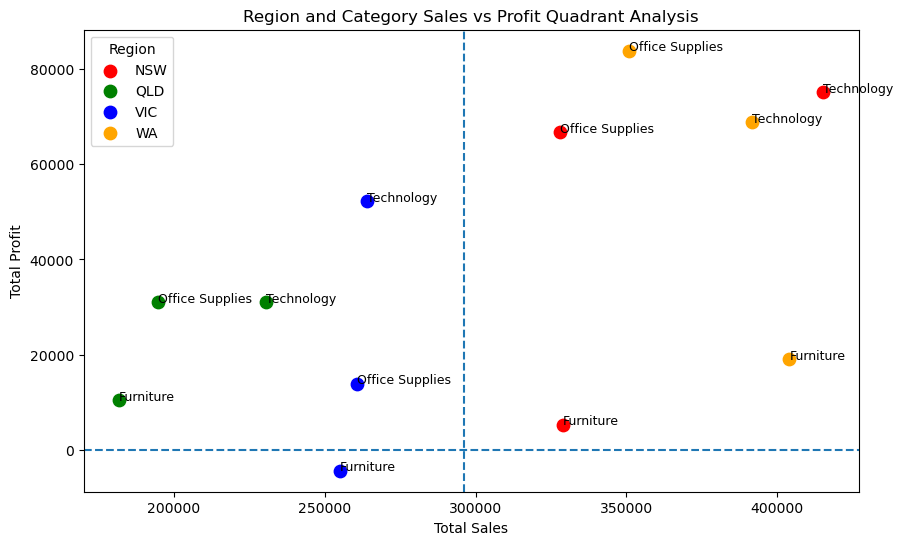

In [13]:
# Colour mapping for regions
region_colors = {
    'NSW': 'red',
    'VIC': 'blue',
    'QLD': 'green',
    'WA': 'orange'
}

plt.figure(figsize=(10, 6))

# Plot one region at a time so each region gets its own colour
for region in sorted(region_category_summary['Region'].unique()):
    region_data = region_category_summary[region_category_summary['Region'] == region]
    
    plt.scatter(
        region_data['total_sales'],
        region_data['total_profit'],
        label=region,
        color=region_colors.get(region),
        s=80
    )

    # Add category labels
    for i, row in region_data.iterrows():
        plt.text(
            row['total_sales'],
            row['total_profit'],
            row['Category'],
            fontsize=9
        )

# Threshold lines
plt.axvline(sales_threshold, linestyle='--')
plt.axhline(profit_threshold, linestyle='--')

plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.title('Region and Category Sales vs Profit Quadrant Analysis')
plt.legend(title='Region')

plt.show()

In [14]:
Superstore['Revenue_No_Discount'] = Superstore['Sales'] / (1 - Superstore['Discount'])
Superstore['Discount_Loss'] = Superstore['Revenue_No_Discount'] - Superstore['Sales']

In [15]:
Superstore.head()    

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,Region,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Cost,Margin_%,Revenue_No_Discount,Discount_Loss
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,Australia,VIC,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",25.49,2,0.2,8.60,16.89,33.74,31.8625,6.3725
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,...,Binders,GBC Standard Plastic Binding Systems Combs,5.49,2,0.8,-8.50,13.99,-154.83,27.4500,21.9600
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,...,Labels,Avery 508,18.27,3,0.2,6.62,11.65,36.23,22.8375,4.5675
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,Australia,VIC,...,Storage,SAFCO Boltless Steel Shelving,422.74,3,0.2,-100.40,523.14,-23.75,528.4250,105.6850
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,Australia,NSW,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,30.28,3,0.2,7.57,22.71,25.00,37.8500,7.5700


In [16]:
revenue_no_discount = Superstore['Revenue_No_Discount'].sum()
discount_loss = Superstore['Discount_Loss'].sum()
actual_sales = Superstore['Sales'].sum()
total_cost = Superstore['Cost'].sum()
actual_profit = Superstore['Profit'].sum()

print("Revenue before discount:", revenue_no_discount)
print("Discount loss:", discount_loss)
print("Actual sales:", actual_sales)
print("Total cost:", total_cost)
print("Actual profit:", actual_profit)

print("\nCheck 1: Revenue before discount - Discount loss")
print(revenue_no_discount - discount_loss)

print("\nCheck 2: Actual sales")
print(actual_sales)

print("\nCheck 3: Actual sales - total cost")
print(actual_sales - total_cost)

print("\nCheck 4: Actual profit")
print(actual_profit)

Revenue before discount: 4491044.525631101
Discount loss: 884914.3056311009
Actual sales: 3606130.2199999997
Total cost: 3153070.66
Actual profit: 453059.56

Check 1: Revenue before discount - Discount loss
3606130.2199999997

Check 2: Actual sales
3606130.2199999997

Check 3: Actual sales - total cost
453059.5599999996

Check 4: Actual profit
453059.56


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Overall waterfall values
revenue_no_discount = Superstore['Revenue_No_Discount'].sum()
discount_loss = Superstore['Discount_Loss'].sum()
actual_sales = Superstore['Sales'].sum()
total_cost = Superstore['Cost'].sum()
actual_profit = Superstore['Profit'].sum()

waterfall = pd.DataFrame({
    'Step': [
        'Revenue No Discount',
        'Discount Loss',
        'Actual Sales',
        'Cost',
        'Actual Profit'
    ],
    'Amount': [
        revenue_no_discount,
        -discount_loss,
        actual_sales,
        -total_cost,
        actual_profit
    ],
    'Type': [
        'Start',
        'Decrease',
        'Subtotal',
        'Decrease',
        'End'
    ]
})

waterfall

,Step,Amount,Type
0,Revenue No Discount,4.491045e+06,Start
1,Discount Loss,-8.849143e+05,Decrease
2,Actual Sales,3.606130e+06,Subtotal
3,Cost,-3.153071e+06,Decrease
4,Actual Profit,4.530596e+05,End


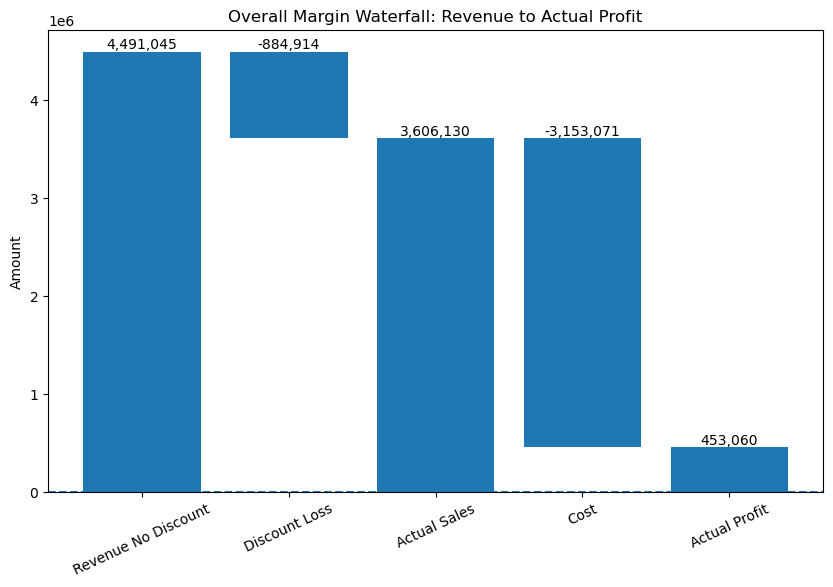

In [18]:
# Create waterfall bar positions

steps = waterfall['Step']
amounts = waterfall['Amount']
types = waterfall['Type']

bottoms = []
bar_values = []

running_total = 0

for amount, step_type in zip(amounts, types):
    if step_type in ['Start', 'Subtotal', 'End']:
        bottoms.append(0)
        bar_values.append(amount)
        running_total = amount
    else:
        bottoms.append(running_total + amount)
        bar_values.append(-amount)
        running_total = running_total + amount

# Plot
plt.figure(figsize=(10, 6))

plt.bar(steps, bar_values, bottom=bottoms)

plt.axhline(0, linestyle='--')

plt.ylabel('Amount')
plt.title('Overall Margin Waterfall: Revenue to Actual Profit')
plt.xticks(rotation=25)

# Add value labels
for i, row in waterfall.iterrows():
    label_value = row['Amount']
    if row['Type'] in ['Start', 'Subtotal', 'End']:
        y_position = row['Amount']
    else:
        y_position = bottoms[i] + bar_values[i]
    
    plt.text(
        i,
        y_position,
        f"{label_value:,.0f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [19]:
category_waterfall = (
    Superstore
    .groupby('Category', observed=True)
    .agg(
        revenue_no_discount=('Revenue_No_Discount', 'sum'),
        discount_loss=('Discount_Loss', 'sum'),
        actual_sales=('Sales', 'sum'),
        total_cost=('Cost', 'sum'),
        actual_profit=('Profit', 'sum')
    )
    .reset_index()
)

category_waterfall['profit_margin_pct'] = (
    category_waterfall['actual_profit'] / category_waterfall['actual_sales'] * 100
)

category_waterfall['discount_loss_pct_of_revenue'] = (
    category_waterfall['discount_loss'] / category_waterfall['revenue_no_discount'] * 100
)

category_waterfall

,Category,revenue_no_discount,discount_loss,actual_sales,total_cost,actual_profit,profit_margin_pct,discount_loss_pct_of_revenue
0,Furniture,1.461651e+06,291791.234163,1169859.93,1139278.53,30581.40,2.614108,19.963124
1,Office Supplies,1.413782e+06,279346.218056,1134436.05,939100.06,195335.99,17.218775,19.758786
2,Technology,1.615611e+06,313776.853413,1301834.24,1074692.07,227142.17,17.447856,19.421558


In [20]:
category_waterfall.sort_values('discount_loss', ascending=False)


,Category,revenue_no_discount,discount_loss,actual_sales,total_cost,actual_profit,profit_margin_pct,discount_loss_pct_of_revenue
2,Technology,1.615611e+06,313776.853413,1301834.24,1074692.07,227142.17,17.447856,19.421558
0,Furniture,1.461651e+06,291791.234163,1169859.93,1139278.53,30581.40,2.614108,19.963124
1,Office Supplies,1.413782e+06,279346.218056,1134436.05,939100.06,195335.99,17.218775,19.758786


In [21]:
category_waterfall.sort_values('profit_margin_pct')

,Category,revenue_no_discount,discount_loss,actual_sales,total_cost,actual_profit,profit_margin_pct,discount_loss_pct_of_revenue
0,Furniture,1.461651e+06,291791.234163,1169859.93,1139278.53,30581.40,2.614108,19.963124
1,Office Supplies,1.413782e+06,279346.218056,1134436.05,939100.06,195335.99,17.218775,19.758786
2,Technology,1.615611e+06,313776.853413,1301834.24,1074692.07,227142.17,17.447856,19.421558


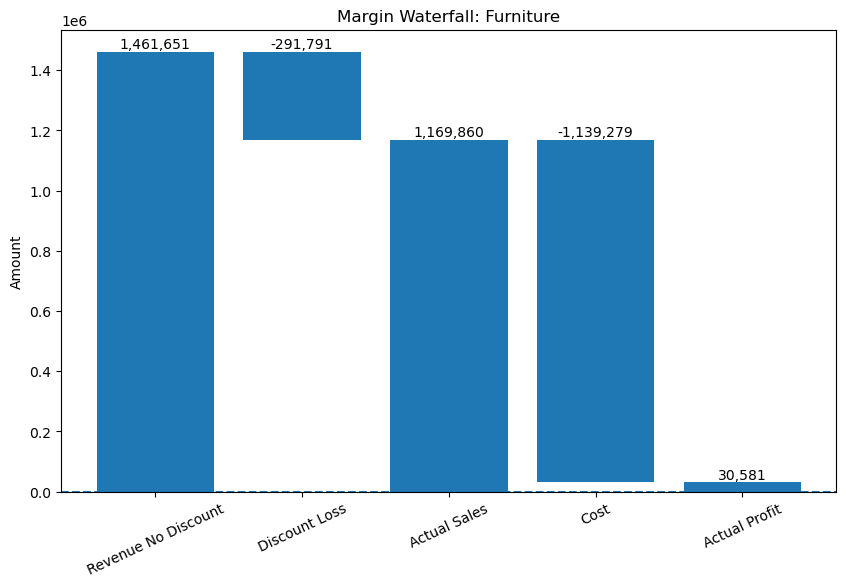

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_category_waterfall(category_name):
    row = category_waterfall[category_waterfall['Category'] == category_name].iloc[0]

    waterfall = pd.DataFrame({
        'Step': [
            'Revenue No Discount',
            'Discount Loss',
            'Actual Sales',
            'Cost',
            'Actual Profit'
        ],
        'Amount': [
            row['revenue_no_discount'],
            -row['discount_loss'],
            row['actual_sales'],
            -row['total_cost'],
            row['actual_profit']
        ],
        'Type': [
            'Start',
            'Decrease',
            'Subtotal',
            'Decrease',
            'End'
        ]
    })

    steps = waterfall['Step']
    amounts = waterfall['Amount']
    types = waterfall['Type']

    bottoms = []
    bar_values = []
    running_total = 0

    for amount, step_type in zip(amounts, types):
        if step_type in ['Start', 'Subtotal', 'End']:
            bottoms.append(0)
            bar_values.append(amount)
            running_total = amount
        else:
            bottoms.append(running_total + amount)
            bar_values.append(-amount)
            running_total = running_total + amount

    plt.figure(figsize=(10, 6))
    plt.bar(steps, bar_values, bottom=bottoms)
    plt.axhline(0, linestyle='--')

    plt.ylabel('Amount')
    plt.title(f'Margin Waterfall: {category_name}')
    plt.xticks(rotation=25)

    for i, row in waterfall.iterrows():
        label_value = row['Amount']
        if row['Type'] in ['Start', 'Subtotal', 'End']:
            y_position = row['Amount']
        else:
            y_position = bottoms[i] + bar_values[i]

        plt.text(
            i,
            y_position,
            f"{label_value:,.0f}",
            ha='center',
            va='bottom'
        )

    plt.show()
    
plot_category_waterfall('Furniture')

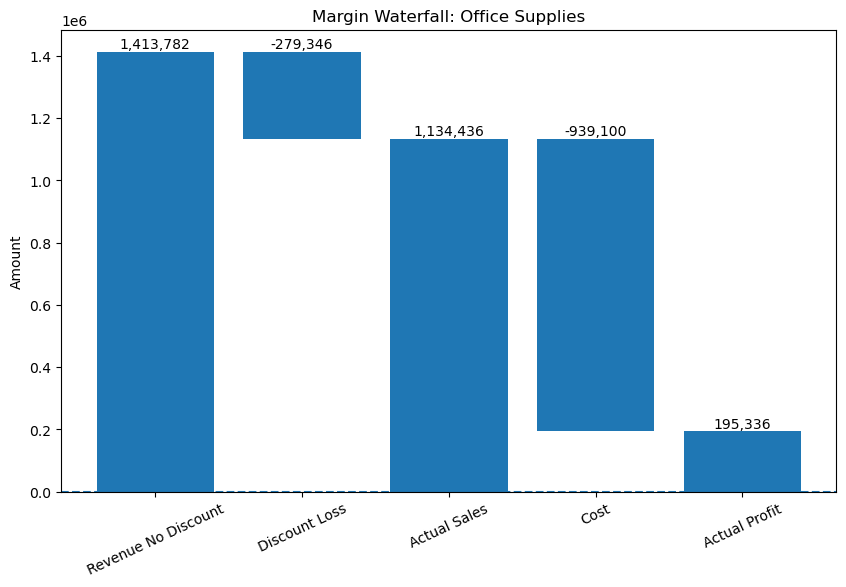

In [23]:
plot_category_waterfall('Office Supplies')

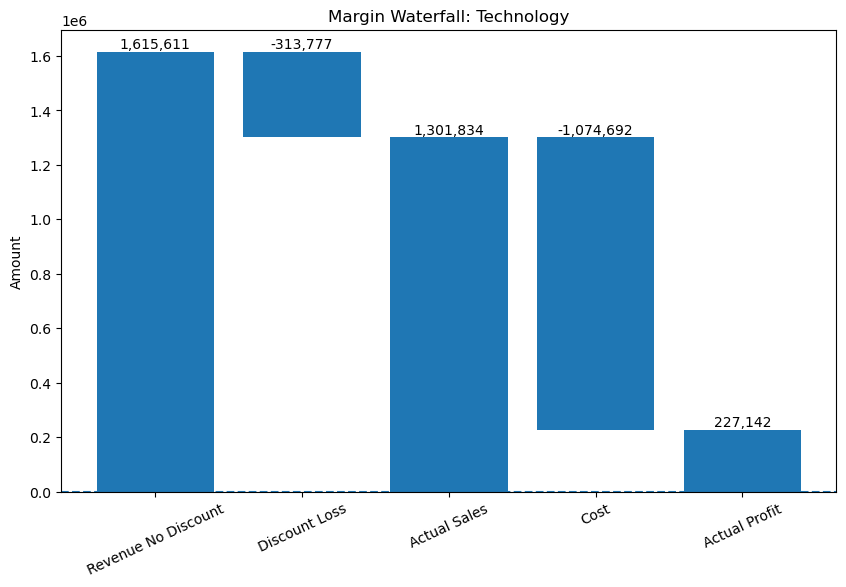

In [24]:
plot_category_waterfall('Technology')

In [25]:
import sqlalchemy

engine = sqlalchemy.create_engine('sqlite:///superstore.db')

# Create reliable Year and Quarter columns before loading into SQL
Superstore['Year'] = Superstore['Order Date'].dt.year
Superstore['Quarter'] = Superstore['Order Date'].dt.quarter

# Reload updated dataframe into SQLite
Superstore.to_sql('superstore', con=engine, if_exists='replace', index=False)

10194

In [26]:
print(Superstore[['Order Date', 'Year', 'Quarter']].head())
print(Superstore[['Order Date', 'Year', 'Quarter']].dtypes)

  Order Date  Year  Quarter
0 2023-01-03  2023        1
1 2023-01-04  2023        1
2 2023-01-04  2023        1
3 2023-01-04  2023        1
4 2023-01-05  2023        1
Order Date    datetime64[ns]
Year                   int32
Quarter                int32
dtype: object


In [27]:
query = """
SELECT
    Region,
    Category,
    Year,
    Quarter,
    SUM(Profit) AS total_profit,
    SUM(Sales) AS total_sales,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS weighted_margin
FROM superstore
GROUP BY
    Region, Category, Year, Quarter
ORDER BY
    Year, Quarter, Region, Category;
"""

result = pd.read_sql_query(query, engine)

result

,Region,Category,Year,Quarter,total_profit,total_sales,weighted_margin
0,NSW,Furniture,2023,1,-2160.03,7033.22,-30.71
1,NSW,Office Supplies,2023,1,626.00,1901.53,32.92
2,NSW,Technology,2023,1,454.35,1699.05,26.74
3,QLD,Furniture,2023,1,2511.24,12982.05,19.34
4,QLD,Office Supplies,2023,1,935.25,5626.61,16.62
...,...,...,...,...,...,...,...
187,VIC,Office Supplies,2026,4,-6189.88,28724.97,-21.55
188,VIC,Technology,2026,4,4230.88,19716.73,21.46
189,WA,Furniture,2026,4,580.83,50335.71,1.15
190,WA,Office Supplies,2026,4,13305.05,50287.04,26.46


In [28]:
query = """
SELECT
    Region,
    Category,
    SUM(Profit) AS total_profit,
    SUM(Sales) AS total_sales,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS overall_weighted_margin_pct
FROM superstore
GROUP BY
    Region,
    Category
ORDER BY
    Region,
    Category;
"""

overall_margin_by_region_category = pd.read_sql_query(query, engine)



from IPython.display import display

for region in sorted(result['Region'].unique()):
    print(f"\nRegion: {region}")
    display(result[result['Region'] == region].reset_index(drop=True))


Region: NSW


,Region,Category,Year,Quarter,total_profit,total_sales,weighted_margin
0,NSW,Furniture,2023,1,-2160.03,7033.22,-30.71
1,NSW,Office Supplies,2023,1,626.00,1901.53,32.92
2,NSW,Technology,2023,1,454.35,1699.05,26.74
3,NSW,Furniture,2023,2,-575.53,12557.83,-4.58
4,NSW,Office Supplies,2023,2,2153.76,11901.33,18.10
5,NSW,Technology,2023,2,1599.52,11100.26,14.41
6,NSW,Furniture,2023,3,2295.89,20789.01,11.04
7,NSW,Office Supplies,2023,3,3303.50,18399.58,17.95
8,NSW,Technology,2023,3,4532.02,15596.74,29.06
9,NSW,Furniture,2023,4,138.09,36442.40,0.38



Region: QLD


,Region,Category,Year,Quarter,total_profit,total_sales,weighted_margin
0,QLD,Furniture,2023,1,2511.24,12982.05,19.34
1,QLD,Office Supplies,2023,1,935.25,5626.61,16.62
2,QLD,Technology,2023,1,697.80,49997.78,1.40
3,QLD,Furniture,2023,2,1198.63,6433.80,18.63
4,QLD,Office Supplies,2023,2,3054.30,17995.68,16.97
5,QLD,Technology,2023,2,2638.00,10482.88,25.16
6,QLD,Furniture,2023,3,1025.58,5774.66,17.76
7,QLD,Office Supplies,2023,3,2166.81,8326.38,26.02
8,QLD,Technology,2023,3,-1019.30,10793.62,-9.44
9,QLD,Furniture,2023,4,1465.46,16609.96,8.82



Region: VIC


,Region,Category,Year,Quarter,total_profit,total_sales,weighted_margin
0,VIC,Furniture,2023,1,-341.44,7106.71,-4.80
1,VIC,Office Supplies,2023,1,-212.65,3947.07,-5.39
2,VIC,Technology,2023,1,769.92,2277.34,33.81
3,VIC,Furniture,2023,2,-495.16,12487.80,-3.97
4,VIC,Office Supplies,2023,2,1409.06,10424.20,13.52
5,VIC,Technology,2023,2,588.83,4069.10,14.47
6,VIC,Furniture,2023,3,-725.48,14477.33,-5.01
7,VIC,Office Supplies,2023,3,82.46,26538.75,0.31
8,VIC,Technology,2023,3,-2463.32,27449.70,-8.97
9,VIC,Furniture,2023,4,-150.99,16938.16,-0.89



Region: WA


,Region,Category,Year,Quarter,total_profit,total_sales,weighted_margin
0,WA,Furniture,2023,1,20.68,10022.61,0.21
1,WA,Office Supplies,2023,1,2121.14,11054.37,19.19
2,WA,Technology,2023,1,925.18,4108.16,22.52
3,WA,Furniture,2023,2,1286.28,14486.75,8.88
4,WA,Office Supplies,2023,2,2852.75,9363.39,30.47
5,WA,Technology,2023,2,2401.39,17088.18,14.05
6,WA,Furniture,2023,3,1893.33,23993.73,7.89
7,WA,Office Supplies,2023,3,6005.04,31979.43,18.78
8,WA,Technology,2023,3,3855.44,21460.78,17.97
9,WA,Furniture,2023,4,1734.55,33157.61,5.23


In [29]:
query = """
SELECT
    Category,
    Region,
    COUNT(*) AS total_transactions,
    SUM(CASE 
            WHEN Discount > 0 THEN 1 
            ELSE 0 
        END) AS discounted_transactions,
    ROUND(
        SUM(CASE 
                WHEN Discount > 0 THEN 1 
                ELSE 0 
            END) * 100.0 / COUNT(*),
        2
    ) AS discounted_transaction_pct,
    ROUND(AVG(Profit), 2) AS avg_profit_per_transaction
FROM superstore
GROUP BY
    Category,
    Region
ORDER BY
    Category,
    Region;
"""

discount_profit_summary = pd.read_sql_query(query, engine)

discount_profit_summary

,Category,Region,total_transactions,discounted_transactions,discounted_transaction_pct,avg_profit_per_transaction
0,Furniture,NSW,649,391,60.25,8.23
1,Furniture,QLD,332,172,51.81,31.61
2,Furniture,VIC,485,329,67.84,-8.96
3,Furniture,WA,735,429,58.37,25.97
4,Office Supplies,NSW,1792,819,45.70,37.19
5,Office Supplies,QLD,995,503,50.55,31.13
6,Office Supplies,VIC,1430,913,63.85,9.72
7,Office Supplies,WA,1911,695,36.37,43.86
8,Technology,NSW,545,228,41.83,137.77
9,Technology,QLD,293,140,47.78,105.76


In [30]:
query = """
SELECT
    Category,
    Region,
    ROUND(AVG(Discount) * 100, 2) AS avg_discount_pct
FROM superstore
GROUP BY
    Category,
    Region
ORDER BY
    Category,
    Region;
"""

avg_discount_summary = pd.read_sql_query(query, engine)

avg_discount_summary

,Category,Region,avg_discount_pct
0,Furniture,NSW,15.44
1,Furniture,QLD,12.15
2,Furniture,VIC,29.74
3,Furniture,WA,13.05
4,Office Supplies,NSW,14.03
5,Office Supplies,QLD,16.74
6,Office Supplies,VIC,25.36
7,Office Supplies,WA,9.29
8,Technology,NSW,14.07
9,Technology,QLD,10.78


In [31]:
query = """
SELECT
    Category,
    Region,
    Discount AS discount_level,
    COUNT(*) AS total_transactions,
    ROUND(AVG(Profit), 2) AS avg_profit_per_transaction,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(SUM(Sales), 2) AS total_sales
FROM superstore
GROUP BY
    Category,
    Region,
    Discount
ORDER BY
    Category,
    Region,
    Discount;
"""

discount_level_profit_summary = pd.read_sql_query(query, engine)

discount_level_profit_summary

,Category,Region,discount_level,total_transactions,avg_profit_per_transaction,total_profit,total_sales
0,Furniture,NSW,0.00,258,81.45,21013.65,84669.91
1,Furniture,NSW,0.10,76,145.03,11022.02,72283.02
2,Furniture,NSW,0.20,146,12.45,1817.71,53312.14
3,Furniture,NSW,0.30,82,-74.10,-6075.87,60468.95
4,Furniture,NSW,0.40,59,-258.50,-15251.58,46063.33
5,Furniture,NSW,0.50,18,-366.47,-6596.50,11328.14
6,Furniture,NSW,0.60,8,-35.47,-283.80,609.60
7,Furniture,NSW,0.70,2,-153.14,-306.28,224.12
8,Furniture,QLD,0.00,160,142.61,22817.96,101756.75
9,Furniture,QLD,0.20,145,9.52,1380.60,46915.87


In [32]:
query = """
SELECT
    Category,
    Region,

    ROUND(AVG(CASE 
        WHEN Discount < 0.30 THEN Quantity 
    END), 2) AS avg_quantity_below_30_discount,

    ROUND(AVG(CASE 
        WHEN Discount >= 0.30 THEN Quantity 
    END), 2) AS avg_quantity_30_plus_discount,

    COUNT(CASE 
        WHEN Discount < 0.30 THEN 1 
    END) AS transactions_below_30_discount,

    COUNT(CASE 
        WHEN Discount >= 0.30 THEN 1 
    END) AS transactions_30_plus_discount

FROM superstore
GROUP BY
    Category,
    Region
ORDER BY
    Category,
    Region;
"""

quantity_discount_comparison = pd.read_sql_query(query, engine)

quantity_discount_comparison

,Category,Region,avg_quantity_below_30_discount,avg_quantity_30_plus_discount,transactions_below_30_discount,transactions_30_plus_discount
0,Furniture,NSW,3.73,3.70,480,169
1,Furniture,QLD,3.81,4.74,305,27
2,Furniture,VIC,3.90,3.74,159,326
3,Furniture,WA,3.83,4.12,702,33
4,Office Supplies,NSW,3.78,3.63,1615,177
5,Office Supplies,QLD,3.77,4.11,863,132
6,Office Supplies,VIC,3.76,3.95,1127,303
7,Office Supplies,WA,3.79,4.38,1834,77
8,Technology,NSW,3.64,3.80,412,133
9,Technology,QLD,3.86,2.67,281,12


In [33]:
# Question 1 - Margin by region, category, quarter
result.to_csv('margin_by_region_category_quarter.csv', index=False)

# Question 1 - Overall margin summary
overall_margin_by_region_category.to_csv('overall_margin_by_region_category.csv', index=False)

# Question 2 - Discount frequency and profit
discount_profit_summary.to_csv('discount_profit_summary.csv', index=False)

# Question 2 - Average discount by category and region
avg_discount_summary.to_csv('avg_discount_summary.csv', index=False)

# Question 2 - Discount threshold analysis
discount_level_profit_summary.to_csv('discount_threshold_analysis.csv', index=False)

# Question 3 - Quantity vs discount comparison
quantity_discount_comparison.to_csv('quantity_discount_comparison.csv', index=False)

# Main cleaned dataset
Superstore.to_csv('au_superstore_final.csv', index=False)

print("All files exported successfully")

All files exported successfully
